# Traffic Counts Generation

This notebook explores how input traffic will be used for Davis on 2nd street. This numbers will serve as a traffic volume baseline for Vissim.

In [1]:
# Loading Dependencies
import geopandas as gpd
import osmnx as ox
import network_functions as nf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

from collections import Counter, defaultdict
from itertools import pairwise 
from shapely.geometry import Polygon, LineString, Point

### Calling our Data Sources

`link_data_gdf` is the GeoDataFrame from [Replica](https://www.replicahq.com/). This specific study used can be accessed [here](https://studio.replicahq.com/places/studies/oudkca1)

`traffic_data` is the .parquet file from the Replica dataset. It was originally a .csv but I turn it into a .parquet file for better local storage.

In [2]:
link_data_gdf = gpd.read_file("replica-itc_2025-11_04_25-network_link_layer.geojson")
traffic_data = pd.read_parquet("replica-itc_2025-10_28_25-trips_dataset.parquet")

# Filter for car trips
car_trips = traffic_data[traffic_data['primary_mode'].str.contains('auto')].reset_index(drop=True)
coord_cols = [
    "origin_bgrp_lng_2020","origin_bgrp_lat_2020",
    "destination_bgrp_lng_2020","destination_bgrp_lat_2020"
]
car_trips = car_trips.dropna(subset=coord_cols)

## Generating Routes

This was a pain in the butt.

### Building Davis Network

In [3]:
location = "Davis, California, USA"
poly = ox.geocode_to_gdf(location)
G = ox.graph_from_place(location, network_type="drive")
G = ox.truncate.largest_component(G, strongly=False)   # v2.0.6 API
G = ox.routing.add_edge_speeds(G)                      # adds 'speed_kph'
G = ox.routing.add_edge_travel_times(G)                # adds 'travel_time' (s)

### Generating Quick Trip Times

In [4]:
car_trips["tod"] = pd.to_timedelta(car_trips["trip_start_time"])
car_trips["trip_hour"] = (car_trips["tod"].dt.total_seconds() // 3600).astype(int)

### Building Origin-Dest Node Dists & Paths

In [5]:
origin_nodes = ox.nearest_nodes(
    G,
    car_trips["origin_bgrp_lng_2020"].to_numpy(),
    car_trips["origin_bgrp_lat_2020"].to_numpy(),
)
destination_nodes = ox.nearest_nodes(
    G,
    car_trips["destination_bgrp_lng_2020"].to_numpy(),
    car_trips["destination_bgrp_lat_2020"].to_numpy(),
)

dists, paths = nf.path_dijkstra(
    origins=origin_nodes,
    destinations=destination_nodes,
    G=G,
    dist_param="travel_time",
    origins_in_nodes=True,
    destinations_in_nodes=True,
    pairs=True,
    verbose=True,
)

pairs chosen
sources made. length 49


100%|██████████| 49/49 [00:00<00:00, 1733.96it/s]


In [6]:
od_counts = Counter(zip(origin_nodes, destination_nodes))

edges = defaultdict(int)
for (origin, destination), path in paths.items():
    k = od_counts.get((origin, destination), 1)
    for u, v in pairwise(path):
        edges[(u, v)] += k

edge = ox.graph_to_gdfs(G, nodes=False, edges=True)
edge_reset = edge.reset_index()

# vectorized (no row-wise apply)
edge_reset["uv"] = list(zip(edge_reset["u"], edge_reset["v"]))
edge_reset["usage"] = edge_reset["uv"].map(edges).fillna(0).astype(int)

edge_with_usage = edge_reset.drop(columns=["uv"]).set_index(["u", "v", "key"])

edges_gdf = edge_with_usage.assign(use_bin=np.log1p(edge_with_usage["usage"]) // 1)

In [7]:
def ll_to_xy(latlon):  # (lat,lon) -> (lon,lat)
    return (latlon[1], latlon[0])

top_left     = (38.543680985703226, -121.7440795432951)
top_right    = (38.545050789861584, -121.73714115854816)
bottom_right = (38.54333958192836, -121.73654298866767)
bottom_left  = (38.54217103842081,  -121.74365700939322)

from shapely.geometry import Polygon
aoi_wgs84 = gpd.GeoDataFrame(
    geometry=[Polygon([
        ll_to_xy(top_left), ll_to_xy(top_right),
        ll_to_xy(bottom_right), ll_to_xy(bottom_left),
        ll_to_xy(top_left)
    ])],
    crs="EPSG:4326"
)

# project AOI to a local meters CRS to buffer, then back to 4326
aoi_proj = aoi_wgs84.to_crs(ox.settings.default_crs)  # OSMnx default is EPSG:4326; pick a projected CRS instead if you prefer
# Better: use a local UTM; Davis ~ EPSG:32610
aoi_proj = aoi_wgs84.to_crs("EPSG:32610")
aoi_buffered = aoi_proj.buffer(50).to_crs(edges_gdf.crs)  # 50 m buffer, then back to edges CRS

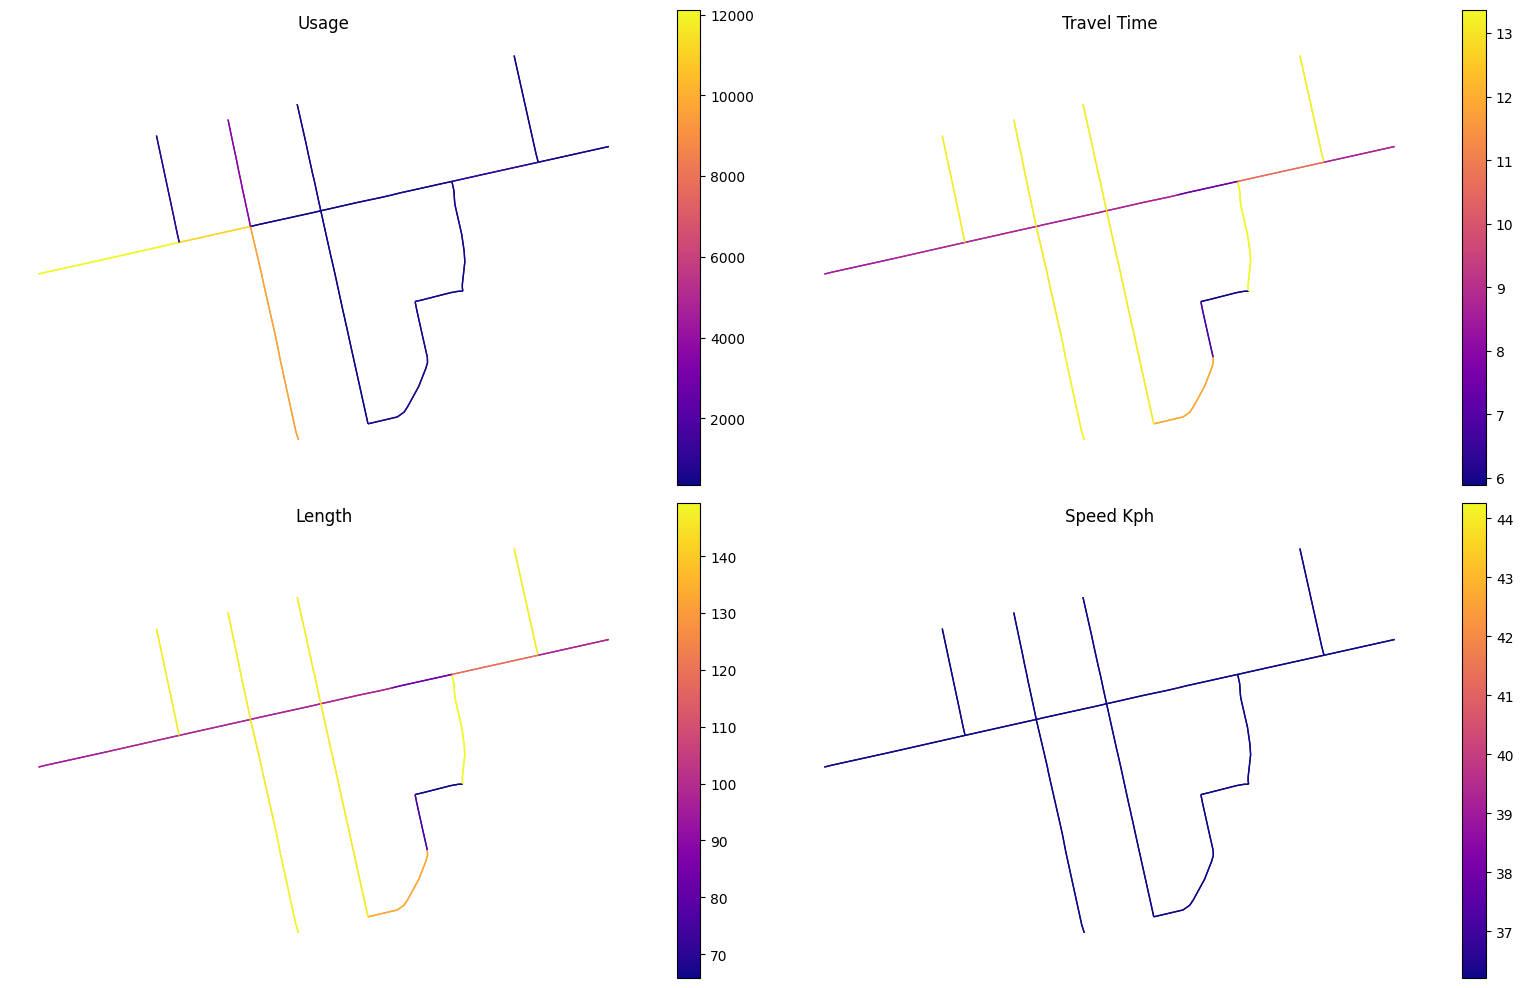

In [10]:
edges_for_join = edges_gdf.to_crs(aoi_buffered.crs)
edges_in_davis = gpd.sjoin(edges_for_join, gpd.GeoDataFrame(geometry=aoi_buffered, crs=aoi_buffered.crs),
                           how="inner", predicate="intersects")
edges_nonzero = edges_in_davis.query("usage > 0")

metrics = ["usage", "travel_time", "length", "speed_kph"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metric in zip(axes.flatten(), metrics):
    edges_nonzero.plot(column=metric, cmap="plasma",
                        legend=True, linewidth=1.0, ax=ax)
    ax.set_title(metric.replace("_", " ").title())
    ax.axis("off")

plt.tight_layout()
plt.show()
